<a href="https://colab.research.google.com/github/ahmedmamdouh111/Netflix-data-science-internship/blob/main/Netflix_Data_Science_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Data Cleaning & Preprocessing

## Data Import and Initial Inspection

In [100]:
  import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data_url = "https://raw.githubusercontent.com/ahmedmamdouh111/Netflix-data-science-internship/main/Dataset.csv"

data = pd.read_csv(data_url)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [ ]:
data.shape

(8790, 10)

In [ ]:
data.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

In [ ]:
data['rating'].unique()

array(['PG-13', 'TV-MA', 'TV-PG', 'TV-14', 'TV-Y7', 'TV-Y', 'PG', 'TV-G',
       'R', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [ ]:
data['rating'].value_counts()

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


In [ ]:
data['duration'].unique()

array(['90 min', '1 Season', '91 min', '125 min', '9 Seasons', '104 min',
       '87 min', '127 min', '76 min', '71 min', '131 min', '39 min',
       '36 min', '34 min', '35 min', '46 min', '67 min', '65 min',
       '61 min', '166 min', '103 min', '97 min', '106 min', '2 Seasons',
       '4 Seasons', '147 min', '94 min', '161 min', '111 min', '110 min',
       '105 min', '96 min', '124 min', '116 min', '98 min', '115 min',
       '122 min', '55 min', '99 min', '88 min', '100 min', '6 Seasons',
       '3 Seasons', '23 min', '102 min', '93 min', '95 min', '85 min',
       '83 min', '182 min', '5 Seasons', '92 min', '84 min', '48 min',
       '145 min', '119 min', '80 min', '128 min', '143 min', '273 min',
       '117 min', '114 min', '118 min', '108 min', '37 min', '121 min',
       '63 min', '142 min', '113 min', '154 min', '120 min', '82 min',
       '109 min', '101 min', '86 min', '77 min', '229 min', '15 min',
       '89 min', '156 min', '112 min', '107 min', '129 min', '44 min',
  

In [ ]:
data.groupby('type')['duration'].value_counts()

type     duration  
Movie    90 min        152
         93 min        146
         94 min        146
         97 min        146
         91 min        144
                      ... 
TV Show  12 Seasons      2
         13 Seasons      2
         15 Seasons      2
         11 Seasons      1
         17 Seasons      1
Name: count, Length: 220, dtype: int64

In [ ]:
data['listed_in'].head(10)

,listed_in
0,Documentaries
1,"Crime TV Shows, International TV Shows, TV Act..."
2,"TV Dramas, TV Horror, TV Mysteries"
3,"Children & Family Movies, Comedies"
4,"Dramas, Independent Movies, International Movies"
5,"British TV Shows, Reality TV"
6,"Comedies, Dramas"
7,"Children & Family Movies, Comedies, Music & Mu..."
8,"Dramas, International Movies"
9,"Children & Family Movies, Music & Musicals"


In [ ]:
data['country'].unique()

array(['United States', 'France', 'Brazil', 'United Kingdom', 'India',
       'Germany', 'Pakistan', 'Not Given', 'China', 'South Africa',
       'Japan', 'Nigeria', 'Spain', 'Philippines', 'Australia',
       'Argentina', 'Canada', 'Hong Kong', 'Italy', 'New Zealand',
       'Egypt', 'Colombia', 'Mexico', 'Belgium', 'Switzerland', 'Taiwan',
       'Bulgaria', 'Poland', 'South Korea', 'Saudi Arabia', 'Thailand',
       'Indonesia', 'Kuwait', 'Malaysia', 'Vietnam', 'Lebanon', 'Romania',
       'Syria', 'United Arab Emirates', 'Sweden', 'Mauritius', 'Austria',
       'Turkey', 'Czech Republic', 'Cameroon', 'Netherlands', 'Ireland',
       'Russia', 'Kenya', 'Chile', 'Uruguay', 'Bangladesh', 'Portugal',
       'Hungary', 'Norway', 'Singapore', 'Iceland', 'Serbia', 'Namibia',
       'Peru', 'Mozambique', 'Ghana', 'Zimbabwe', 'Israel', 'Finland',
       'Denmark', 'Paraguay', 'Cambodia', 'Georgia', 'Soviet Union',
       'Greece', 'West Germany', 'Iran', 'Venezuela', 'Slovenia',
       'Gua

In [ ]:
data['country'].value_counts()

,count
country,
United States,3240
India,1057
United Kingdom,638
Pakistan,421
Not Given,287
...,...
Luxembourg,1
Senegal,1
Belarus,1


## Data Cleaning Decisions

After inspecting the dataset, several cleaning decisions were made to improve data quality while avoiding unnecessary assumptions.

- Missing or unavailable country values labeled as `Not Given` were replaced with `Unknown` instead of using the mode, to avoid assigning an incorrect country.
- Missing director values labeled as `Not Given` were also replaced with `Unknown`.
- The `date_added` column was converted to datetime format for easier time-based analysis.
- Duplicate records were checked while excluding `show_id`, since each record has a unique identifier.

In [ ]:
data['country']=data['country'].replace('Not Given','Unknown')

In [ ]:
(data['country'] == 'Not Given').sum()

np.int64(0)

In [ ]:
data['release_year'].describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
data['date_added'].value_counts()

,count
date_added,
1/1/2020,110
11/1/2019,91
3/1/2018,75
12/31/2019,74
10/1/2018,71
...,...
12/2/2015,1
9/22/2016,1
9/17/2016,1


In [ ]:
data['date_added'] = pd.to_datetime(data['date_added'])

In [ ]:
data['date_added'].dtype

dtype('<M8[ns]')

In [ ]:
data['date_added'].describe()

,date_added
count,8790
mean,2019-05-17 21:44:01.638225408
min,2008-01-01 00:00:00
25%,2018-04-06 00:00:00
50%,2019-07-03 00:00:00
75%,2020-08-19 18:00:00
max,2021-09-25 00:00:00


In [ ]:
data['director'].unique()

array(['Kirsten Johnson', 'Julien Leclercq', 'Mike Flanagan', ...,
       'Majid Al Ansari', 'Peter Hewitt', 'Mozez Singh'], dtype=object)

In [ ]:
data['director'].value_counts()

,count
director,
Not Given,2588
Rajiv Chilaka,20
Alastair Fothergill,18
"Raúl Campos, Jan Suter",18
Marcus Raboy,16
...,...
Mark Risley,1
Kirati Nakintanon,1
Christian De Vita,1


In [ ]:
data['director']=data['director'].replace('Not Given','Unknown')

In [ ]:
data['show_id'].nunique()

8790

In [ ]:
data['title'].value_counts()

,count
title,
9-Feb,2
15-Aug,2
22-Jul,2
"Septiembre, un llanto en silencio",1
Set Up,1
...,...
Sei,1
Superlopez,1
Oversize Cops,1


In [ ]:
data.loc[data['title']=='9-Feb']

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
393,s3997,TV Show,9-Feb,Unknown,Pakistan,2019-03-20,2018,TV-14,1 Season,"International TV Shows, TV Dramas"
537,s5965,TV Show,9-Feb,Unknown,Pakistan,2019-03-20,2018,TV-14,1 Season,"International TV Shows, TV Dramas"


## Duplicate Handling

The `show_id` column is unique for each record, so it was excluded when checking for duplicate content.

Duplicate records were identified based on all remaining columns, then only the first occurrence was kept.

In [ ]:
data.loc[data.duplicated(subset=data.columns.drop('show_id'),keep=False)]

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
393,s3997,TV Show,9-Feb,Unknown,Pakistan,2019-03-20,2018,TV-14,1 Season,"International TV Shows, TV Dramas"
537,s5965,TV Show,9-Feb,Unknown,Pakistan,2019-03-20,2018,TV-14,1 Season,"International TV Shows, TV Dramas"
2925,s3963,Movie,15-Aug,Swapnaneel Jayakar,India,2019-03-29,2019,TV-14,124 min,"Comedies, Dramas, Independent Movies"
3285,s4523,Movie,22-Jul,Paul Greengrass,Norway,2018-10-10,2018,R,144 min,"Dramas, Thrillers"
4260,s5966,Movie,22-Jul,Paul Greengrass,Norway,2018-10-10,2018,R,144 min,"Dramas, Thrillers"
4261,s5967,Movie,15-Aug,Swapnaneel Jayakar,India,2019-03-29,2019,TV-14,124 min,"Comedies, Dramas, Independent Movies"


In [ ]:
data=data.drop_duplicates(subset=data.columns.drop('show_id'),keep='first')

In [ ]:
data.duplicated(subset=data.columns.drop('show_id')).sum()

np.int64(0)

In [ ]:
data.shape

(8787, 10)

In [ ]:
data['title'].nunique()

8787

In [ ]:
(data == 'Not Given').sum()

,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


## Final Data Validation

After completing the cleaning steps, the dataset is validated again to confirm that:

- No missing values remain.
- Duplicate content records have been removed.
- Data types are appropriate for further analysis.
- The cleaned dataset is ready for exploratory data analysis and modeling.

In [ ]:
print("Shape:", data.shape)
print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicate records:")
print(data.duplicated(subset=data.columns.drop('show_id')).sum())

print("\nData types:")
print(data.dtypes)

Shape: (8787, 10)

Missing values:
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

Duplicate records:
0

Data types:
show_id                 object
type                    object
title                   object
director                object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
dtype: object


In [ ]:
data.to_csv('netflix_cleaned.csv',index=False)

# Task 2: Exploratory Data Analysis (EDA)

In [ ]:
data.shape

(8787, 10)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8787 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8787 non-null   object        
 1   type          8787 non-null   object        
 2   title         8787 non-null   object        
 3   director      8787 non-null   object        
 4   country       8787 non-null   object        
 5   date_added    8787 non-null   datetime64[ns]
 6   release_year  8787 non-null   int64         
 7   rating        8787 non-null   object        
 8   duration      8787 non-null   object        
 9   listed_in     8787 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 755.1+ KB


In [ ]:
data.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
data['type'].value_counts(normalize=True) * 100

,proportion
type,
Movie,69.693866
TV Show,30.306134


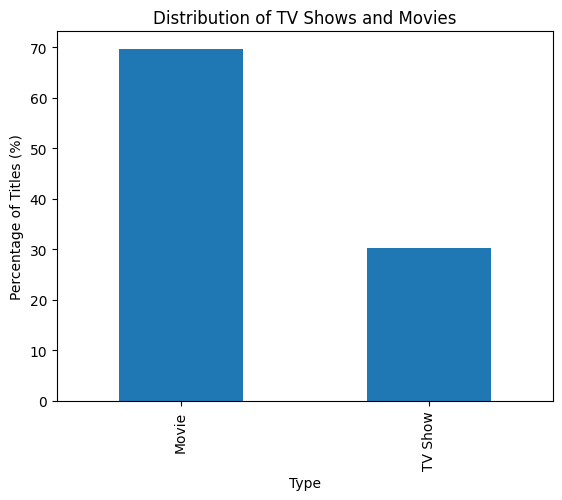

In [ ]:
(data['type'].value_counts(normalize=True) * 100).plot(kind='bar')
plt.title('Distribution of TV Shows and Movies')
plt.xlabel('Type')
plt.ylabel('Percentage of Titles (%)')
plt.show()

### Insight
Movies represent approximately 69.7% of the titles in the dataset, while TV Shows account for 30.3%.

In [ ]:
country_counts = data.loc[data['country']!='Unknown','country'].value_counts()
country_counts

,count
country,
United States,3240
India,1056
United Kingdom,638
Pakistan,420
Canada,271
...,...
Luxembourg,1
Senegal,1
Belarus,1


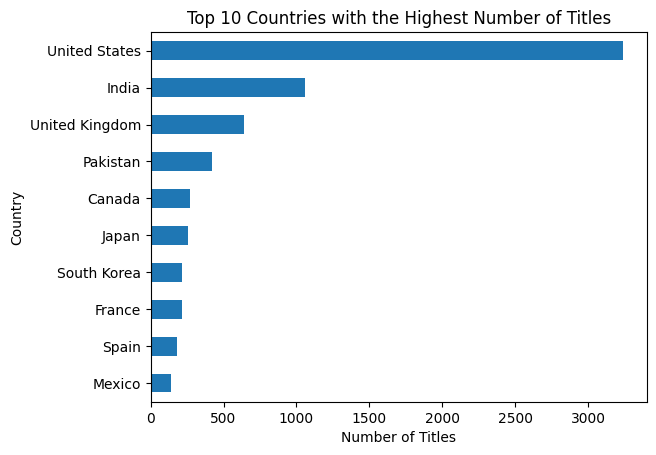

In [ ]:
country_counts.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Countries with the Highest Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

### Insight
The United States has the highest number of titles in the dataset (3,240), followed by India (1,056) and the United Kingdom (638). Pakistan and Canada complete the top five.

In [ ]:
categories = data['listed_in'].str.split(',').explode().str.strip()

In [ ]:
categories.value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2424
Comedies,1673
International TV Shows,1348
Documentaries,869
Action & Adventure,859
TV Dramas,761
Independent Movies,755
Children & Family Movies,641


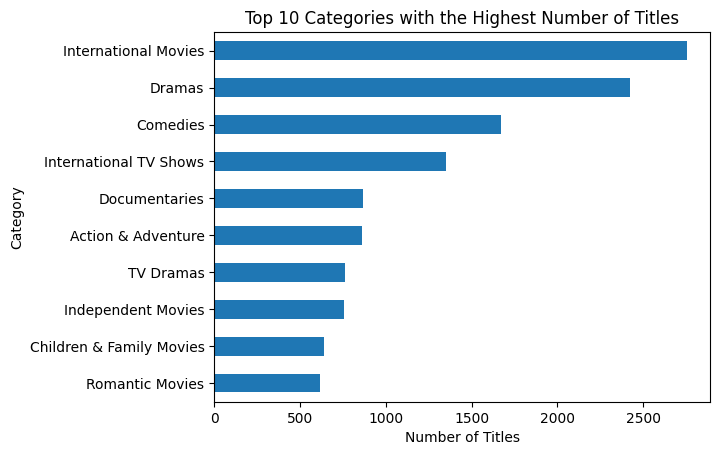

In [ ]:
categories.value_counts().head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Categories with the Highest Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Category')
plt.show()

### Insight
International Movies is the most common category in the dataset with 2,752 titles, followed by Dramas with 2,424 titles and Comedies with 1,673 titles. International TV Shows also represent a large portion of the content with 1,348 titles.

In [ ]:
release_year_counts = data['release_year'].value_counts().sort_index()
release_year_counts

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1030
2018,1144
2019,1029


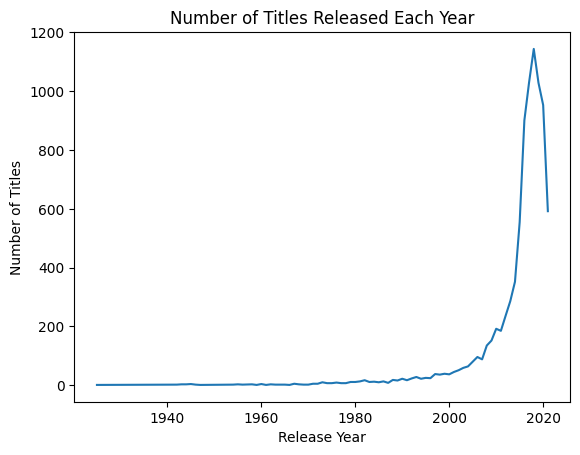

In [ ]:
release_year_counts.plot(kind='line')
plt.title('Number of Titles Released Each Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

### Insight
The number of titles released increased over time, with a noticeable rise during the last two decades. The growth became much stronger in the 2010s, reaching a peak around 2018–2019, followed by a decline in the most recent years shown in the dataset.

In [ ]:
data['rating'].value_counts()

,count
rating,
TV-MA,3205
TV-14,2155
TV-PG,861
R,798
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


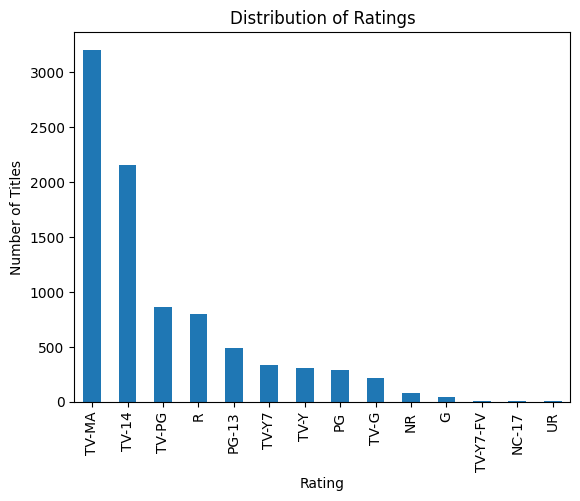

In [ ]:
data['rating'].value_counts().plot(kind='bar')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.show()

### Insight
TV-MA is the most common rating in the dataset with 3,205 titles, followed by TV-14 with 2,155 titles. These two ratings dominate the dataset, while ratings such as NC-17 and UR appear very rarely.

In [ ]:
data_over_years = data['date_added'].dt.year.value_counts().sort_index()
data_over_years

,count
date_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,426


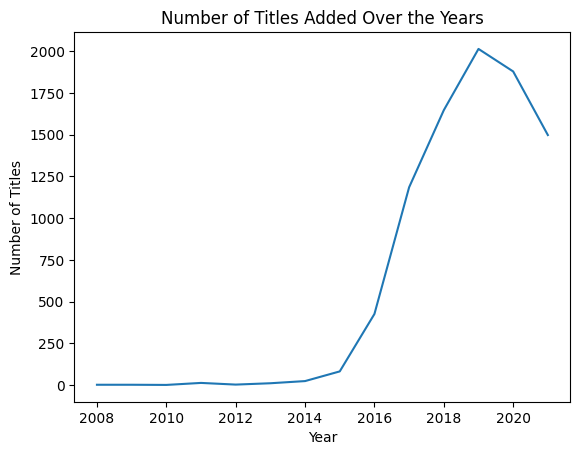

In [ ]:
data_over_years.plot(kind='line')
plt.title('Number of Titles Added Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

### Insight
The number of titles added to Netflix increased rapidly after 2015, reaching its highest level in 2019 with 2,014 titles. After 2019, the number of additions declined in 2020 and 2021.

In [ ]:
movie_duration = (data.loc[data['type'] == 'Movie', 'duration'].str.replace('min', '').str.strip().astype(int))
movie_duration

,duration
0,90
3,91
4,125
6,104
7,87
...,...
8702,103
8707,75
8716,136
8763,89


In [ ]:
movie_duration.describe()

,duration
count,6124.000000
mean,99.573645
std,28.280425
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


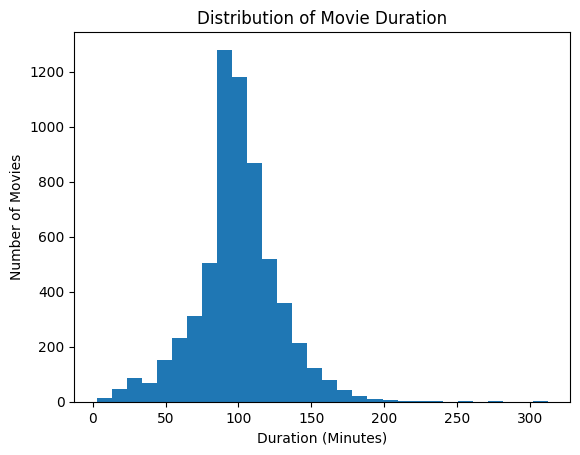

In [ ]:
movie_duration.plot(kind='hist', bins=30)
plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')
plt.show()

### Insight
Most movies have durations concentrated around 80 to 120 minutes, with the highest frequency near 90–100 minutes. The distribution has a longer right tail, indicating a small number of unusually long movies.

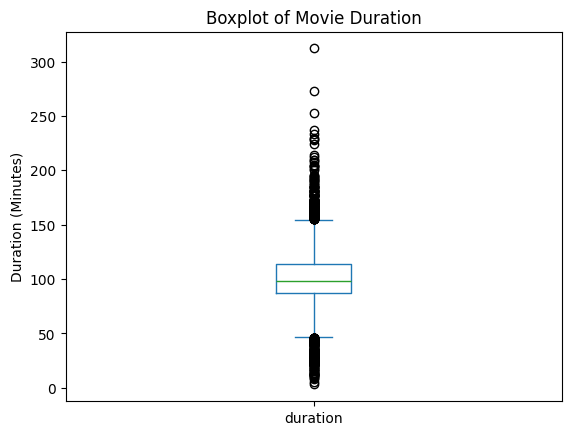

In [ ]:
movie_duration.plot(kind='box')
plt.title('Boxplot of Movie Duration')
plt.ylabel('Duration (Minutes)')
plt.show()

### Insight
The boxplot shows several short and long movies outside the typical duration range. Using the IQR rule, durations below approximately 46.5 minutes or above 154.5 minutes are considered potential outliers. However, these values may represent legitimate short films or unusually long movies, so they should not be removed automatically.

In [ ]:
tv_duration = (data.loc[data['type'] == 'TV Show', 'duration'].str.replace('Seasons', '').str.replace('Season', '').str.strip().astype(int))
tv_duration

,duration
1,1
2,1
5,9
17,1
18,1
...,...
8785,2
8786,3
8787,1
8788,1


In [ ]:
data.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
tv_duration.describe()

,duration
count,2663.000000
mean,1.752159
std,1.550844
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,17.000000


### Insight
Most TV Shows in the dataset have a small number of seasons. The median is 1 season, and 75% of TV Shows have 2 seasons or fewer. A small number of shows extend to many seasons, with the maximum reaching 17 seasons.

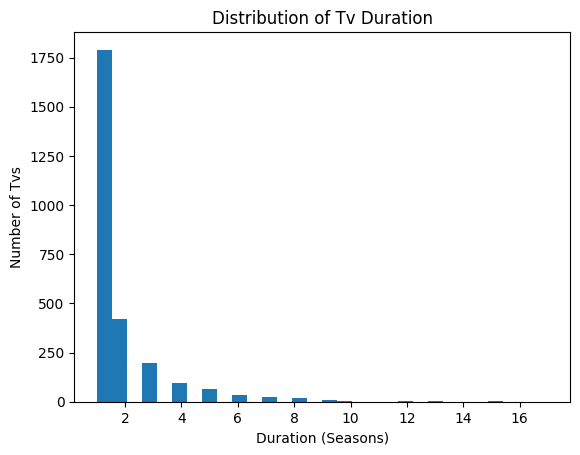

In [ ]:
tv_duration.plot(kind='hist', bins=30)
plt.title('Distribution of Tv Duration')
plt.xlabel('Duration (Seasons)')
plt.ylabel('Number of Tvs')
plt.show()

### Insight
Most TV Shows in the dataset have only one season, followed by shows with two seasons. The number of titles decreases sharply as the number of seasons increases, and shows with many seasons are relatively rare.

## Key Findings

- Movies represent about 69.7% of the titles in the dataset, while TV Shows account for about 30.3%.

- The United States has the highest number of titles in the dataset, followed by India and the United Kingdom.

- International Movies is the most common content category, followed by Dramas and Comedies.

- The number of released titles increased significantly over time, especially during the 2010s.

- TV-MA and TV-14 are the most common ratings in the dataset.

- The number of titles added to Netflix increased rapidly after 2015 and reached its highest level in 2019.

- Most movies have durations concentrated around 80 to 120 minutes, with a median duration of 98 minutes.

- Most TV Shows have only one or two seasons, while shows with many seasons are relatively rare.

In [ ]:
data.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


# Task 3: Recommendation System Analysis

## 1. Feature Selection and Inspection

We will build a content-based recommendation system using selected content features such as category, director, content type, and rating.

In [ ]:
data[['listed_in', 'director', 'type', 'rating']].head(10)

,listed_in,director,type,rating
0,Documentaries,Kirsten Johnson,Movie,PG-13
1,"Crime TV Shows, International TV Shows, TV Act...",Julien Leclercq,TV Show,TV-MA
2,"TV Dramas, TV Horror, TV Mysteries",Mike Flanagan,TV Show,TV-MA
3,"Children & Family Movies, Comedies",Bruno Garotti,Movie,TV-PG
4,"Dramas, Independent Movies, International Movies",Haile Gerima,Movie,TV-MA
5,"British TV Shows, Reality TV",Andy Devonshire,TV Show,TV-14
6,"Comedies, Dramas",Theodore Melfi,Movie,PG-13
7,"Children & Family Movies, Comedies, Music & Mu...",Suhas Kadav,Movie,TV-Y7
8,"Dramas, International Movies",Christian Schwochow,Movie,TV-MA
9,"Children & Family Movies, Music & Musicals",Suhas Kadav,Movie,TV-Y7


In [ ]:
data[['listed_in', 'director', 'type', 'rating']].isin(['Unknown']).sum()

,0
listed_in,0
director,2587
type,0
rating,0


In [ ]:
data[['listed_in', 'director', 'type', 'rating']].isnull().sum()

,0
listed_in,0
director,0
type,0
rating,0


In [ ]:
rec_data = data.copy().reset_index(drop=True)

In [ ]:
rec_data['director'] = rec_data['director'].replace('Unknown', '')

In [ ]:
rec_data[['listed_in', 'director', 'type', 'rating']].isin(['Unknown']).sum()

,0
listed_in,0
director,0
type,0
rating,0


In [ ]:
rec_data[['listed_in', 'director', 'type', 'rating']].isnull().sum()

,0
listed_in,0
director,0
type,0
rating,0


In [ ]:
rec_data[['listed_in', 'director', 'type', 'rating']].head(10)

,listed_in,director,type,rating
0,Documentaries,Kirsten Johnson,Movie,PG-13
1,"Crime TV Shows, International TV Shows, TV Act...",Julien Leclercq,TV Show,TV-MA
2,"TV Dramas, TV Horror, TV Mysteries",Mike Flanagan,TV Show,TV-MA
3,"Children & Family Movies, Comedies",Bruno Garotti,Movie,TV-PG
4,"Dramas, Independent Movies, International Movies",Haile Gerima,Movie,TV-MA
5,"British TV Shows, Reality TV",Andy Devonshire,TV Show,TV-14
6,"Comedies, Dramas",Theodore Melfi,Movie,PG-13
7,"Children & Family Movies, Comedies, Music & Mu...",Suhas Kadav,Movie,TV-Y7
8,"Dramas, International Movies",Christian Schwochow,Movie,TV-MA
9,"Children & Family Movies, Music & Musicals",Suhas Kadav,Movie,TV-Y7


In [ ]:
rec_data['director_clean'] = (
    rec_data['director']
    .str.replace(' ', '', regex=False)
    .str.lower()
)

In [ ]:
rec_data['combined_features'] = (rec_data['listed_in'] + ' ' + rec_data['director_clean'] + ' ' + rec_data['type'] + ' ' +rec_data['rating']
)

In [ ]:
rec_data[['title', 'combined_features']].head()

,title,combined_features
0,Dick Johnson Is Dead,Documentaries kirstenjohnson Movie PG-13
1,Ganglands,"Crime TV Shows, International TV Shows, TV Act..."
2,Midnight Mass,"TV Dramas, TV Horror, TV Mysteries mikeflanaga..."
3,Confessions of an Invisible Girl,"Children & Family Movies, Comedies brunogarott..."
4,Sankofa,"Dramas, Independent Movies, International Movi..."


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [ ]:
tfidf_matrix = tfidf.fit_transform(rec_data['combined_features'])

In [ ]:
tfidf_matrix.shape

(8787, 5307)

In [ ]:
feature_names = tfidf.get_feature_names_out()
feature_names[:10]

array(['13', '14', '17', 'aadishkeluskar', 'aamirbashir', 'aamirkhan',
       'aanandrai', 'aaronburns', 'aaronhancox', 'aaronhann'],
      dtype=object)

In [ ]:
pd.DataFrame(
    tfidf_matrix[:5, :10].toarray(),
    columns=feature_names[:10]
)

,13,14,17,aadishkeluskar,aamirbashir,aamirkhan,aanandrai,aaronburns,aaronhancox,aaronhann
0,0.349944,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_sim = cosine_similarity(tfidf_matrix)

In [ ]:
cosine_sim.shape

(8787, 8787)

In [ ]:
rec_data[['title', 'type', 'listed_in']].sample(10)

,title,type,listed_in
5866,Shark Busters,Movie,"Dramas, International Movies"
4341,A Wednesday,Movie,"Action & Adventure, Dramas, International Movies"
282,Once Upon a Time in Mumbaai,Movie,"Dramas, International Movies, Music & Musicals"
2681,Article 15,Movie,"Dramas, International Movies, Thrillers"
2041,Light in the Dark,Movie,"Dramas, International Movies"
8280,Caught on Camera,TV Show,"British TV Shows, Crime TV Shows, Docuseries"
7879,Westside,TV Show,Reality TV
5723,Ram Teri Ganga Maili,Movie,"Classic Movies, Dramas, International Movies"
4800,Don't Think Twice,Movie,"Comedies, Dramas, Independent Movies"
7295,Man Like Mobeen,TV Show,"British TV Shows, International TV Shows, TV C..."


## Manual Recommendation Flow

In [ ]:
movie_index = rec_data[rec_data['title'] == 'Kung Fu Panda 2'].index[0]
movie_index

np.int64(723)

In [ ]:
similarity_scores = cosine_sim[movie_index]
similarity_scores[:10]

array([0.07088995, 0.        , 0.        , 0.35124522, 0.0577272 ,
       0.        , 0.11537289, 0.26519546, 0.0393775 , 0.22899254])

In [ ]:
similarity_scores_with_index = list(enumerate(similarity_scores))
similarity_scores_with_index[:10]

[(0, np.float64(0.07088995099187825)),
 (1, np.float64(0.0)),
 (2, np.float64(0.0)),
 (3, np.float64(0.3512452200589693)),
 (4, np.float64(0.057727202661656624)),
 (5, np.float64(0.0)),
 (6, np.float64(0.11537288926054295)),
 (7, np.float64(0.26519545519215265)),
 (8, np.float64(0.0393774992238788)),
 (9, np.float64(0.22899253641656145))]

In [ ]:
sorted_scores = sorted(
    similarity_scores_with_index,
    key=lambda x: x[1],
    reverse=True
)
sorted_scores[:10]

[(723, np.float64(1.0)),
 (176, np.float64(0.5152924663690047)),
 (311, np.float64(0.4724148245330664)),
 (317, np.float64(0.4724148245330664)),
 (330, np.float64(0.4724148245330664)),
 (332, np.float64(0.4724148245330664)),
 (335, np.float64(0.4724148245330664)),
 (387, np.float64(0.4724148245330664)),
 (7025, np.float64(0.4724148245330664)),
 (7588, np.float64(0.4724148245330664))]

In [ ]:
top_5 = sorted_scores[1:6]

In [ ]:
for index, score in top_5:
    print(rec_data.loc[index, 'title'], score)

Keymon and Nani in Space Adventure 0.5152924663690047
ChuChuTV Surprise Eggs Learning Videos (Hindi) 0.4724148245330664
ChuChuTV Bedtime Stories & Moral Stories for Kids (English) 0.4724148245330664
ChuChuTV Bedtime Stories & Moral Stories for Kids (Hindi) 0.4724148245330664
ChuChuTV Surprise Eggs Learning Videos (English) 0.4724148245330664


In [ ]:
rec_data.loc[
    [movie_index] + [index for index, score in top_5],
    ['title', 'type', 'listed_in', 'director', 'rating']
]

,title,type,listed_in,director,rating
723,Kung Fu Panda 2,Movie,"Children & Family Movies, Comedies",Jennifer Yuh Nelson,PG
176,Keymon and Nani in Space Adventure,Movie,"Children & Family Movies, Comedies",,TV-Y
311,ChuChuTV Surprise Eggs Learning Videos (Hindi),Movie,Children & Family Movies,,TV-Y
317,ChuChuTV Bedtime Stories & Moral Stories for K...,Movie,Children & Family Movies,,TV-Y
330,ChuChuTV Bedtime Stories & Moral Stories for K...,Movie,Children & Family Movies,,TV-Y
332,ChuChuTV Surprise Eggs Learning Videos (English),Movie,Children & Family Movies,,TV-Y


## Final Recommendation Function

In [ ]:
def recommendation_system(title, top_n=5):
    matches = rec_data[
        rec_data['title'].str.lower() == title.lower()]
    if matches.empty:
        return "Title not found in the dataset."

    movie_index = matches.index[0]

    similarity_scores = cosine_sim[movie_index]
    similarity_scores_with_index = list(enumerate(similarity_scores))

    sorted_scores = sorted(
    similarity_scores_with_index,
    key=lambda x: x[1],
    reverse=True)

    top_scores = sorted_scores[1:top_n + 1]

    recommended_indices = [index for index, score in top_scores]

    return rec_data.loc[
    recommended_indices,
    ['title', 'type', 'listed_in']]

In [ ]:
recommendation_system("Kung Fu Panda 2")

,title,type,listed_in
176,Keymon and Nani in Space Adventure,Movie,"Children & Family Movies, Comedies"
311,ChuChuTV Surprise Eggs Learning Videos (Hindi),Movie,Children & Family Movies
317,ChuChuTV Bedtime Stories & Moral Stories for K...,Movie,Children & Family Movies
330,ChuChuTV Bedtime Stories & Moral Stories for K...,Movie,Children & Family Movies
332,ChuChuTV Surprise Eggs Learning Videos (English),Movie,Children & Family Movies


In [ ]:
recommendation_system("Murderous Affairs")

,title,type,listed_in
624,Heist,TV Show,"Crime TV Shows, Docuseries"
659,The Irish Mob,TV Show,"Crime TV Shows, Docuseries"
2063,Trial By Media,TV Show,"Crime TV Shows, Docuseries"
6801,Jeffrey Epstein: Filthy Rich,TV Show,"Crime TV Shows, Docuseries"
6997,Trial 4,TV Show,"Crime TV Shows, Docuseries"


### Edge Case Test

The recommendation system is tested with a title that does not exist in the dataset to verify that it handles invalid input without producing an error.

In [ ]:
recommendation_system("Ahmed Mamdouh")

'Title not found in the dataset.'

## Recommendation Quality Evaluation

Since the dataset does not contain user ratings or interaction history, recommendation quality is evaluated based on content similarity.

The evaluation focuses on how well the recommended titles match the selected title in terms of categories and content type.

In [ ]:
target_categories = set(
    rec_data.loc[
        rec_data['title'] == 'Kung Fu Panda 2',
        'listed_in'
    ].iloc[0].split(', ')
)

target_categories

{'Children & Family Movies', 'Comedies'}

In [ ]:
recommended_categories = set(
    rec_data.loc[
        rec_data['title'] == 'Keymon and Nani in Space Adventure',
        'listed_in'
    ].iloc[0].split(', ')
)

recommended_categories

{'Children & Family Movies', 'Comedies'}

In [ ]:
category_overlap = (
    len(target_categories.intersection(recommended_categories))
    /
    len(target_categories.union(recommended_categories))
) * 100

category_overlap

100.0

In [ ]:
recommended_categories2 = set(
    rec_data.loc[
        rec_data['title'] == 'ChuChuTV Surprise Eggs Learning Videos (Hindi)',
        'listed_in'
    ].iloc[0].split(', ')
)

recommended_categories2

{'Children & Family Movies'}

In [ ]:
category_overlap = (
    len(target_categories.intersection(recommended_categories2))
    /
    len(target_categories.union(recommended_categories2))
) * 100

category_overlap

50.0

## Final Recommendation Evaluation

In [ ]:
def evaluate_recommendations(title, top_n=5):

    recommendations = recommendation_system(title, top_n)

    if isinstance(recommendations, str):
        return recommendations

    target = rec_data[
        rec_data['title'].str.lower() == title.lower()
    ].iloc[0]

    target_categories = set(
        category.strip()
        for category in target['listed_in'].split(',')
    )

    evaluation = recommendations.copy()

    def calculate_category_overlap(categories):

        recommended_categories = set(
            category.strip()
            for category in categories.split(',')
        )

        intersection = target_categories.intersection(
            recommended_categories
        )

        union = target_categories.union(
            recommended_categories
        )

        return round(
            len(intersection) / len(union) * 100,
            2
        )

    evaluation['category_overlap_%'] = (
        evaluation['listed_in']
        .apply(calculate_category_overlap)
    )

    evaluation['same_type'] = (
        evaluation['type'] == target['type']
    )

    average_overlap = evaluation['category_overlap_%'].mean()

    same_type_rate = evaluation['same_type'].mean() * 100

    print(f"Evaluation for: {title}")
    print(f"Average Category Overlap: {average_overlap:.2f}%")
    print(f"Same Content Type Rate: {same_type_rate:.2f}%")

    return evaluation

In [ ]:
evaluate_recommendations("Kung Fu Panda 2")

Evaluation for: Kung Fu Panda 2
Average Category Overlap: 60.00%
Same Content Type Rate: 100.00%


,title,type,listed_in,category_overlap_%,same_type
176,Keymon and Nani in Space Adventure,Movie,"Children & Family Movies, Comedies",100.0,True
311,ChuChuTV Surprise Eggs Learning Videos (Hindi),Movie,Children & Family Movies,50.0,True
317,ChuChuTV Bedtime Stories & Moral Stories for K...,Movie,Children & Family Movies,50.0,True
330,ChuChuTV Bedtime Stories & Moral Stories for K...,Movie,Children & Family Movies,50.0,True
332,ChuChuTV Surprise Eggs Learning Videos (English),Movie,Children & Family Movies,50.0,True


In [ ]:
evaluate_recommendations("Murderous Affairs")

Evaluation for: Murderous Affairs
Average Category Overlap: 100.00%
Same Content Type Rate: 100.00%


,title,type,listed_in,category_overlap_%,same_type
624,Heist,TV Show,"Crime TV Shows, Docuseries",100.0,True
659,The Irish Mob,TV Show,"Crime TV Shows, Docuseries",100.0,True
2063,Trial By Media,TV Show,"Crime TV Shows, Docuseries",100.0,True
6801,Jeffrey Epstein: Filthy Rich,TV Show,"Crime TV Shows, Docuseries",100.0,True
6997,Trial 4,TV Show,"Crime TV Shows, Docuseries",100.0,True


## Task 3 Conclusion

A content-based recommendation system was developed using TF-IDF and cosine similarity.

The system recommends similar Netflix titles based on content features such as categories, director, content type, and rating. Recommendation quality was evaluated using category overlap and content type consistency.

The results showed that the system can generate relevant recommendations based on available metadata. However, since the dataset does not include user ratings or interaction history, the recommendations are based only on content similarity.

# Task 4 — Trend Prediction Analysis

## Objective
Analyze historical Netflix content trends using release-year data and build a forecasting model to estimate future content trends.

## 1. Release Year Data Preparation

Before building a forecasting model, we first inspect the release year data to ensure it is suitable for trend analysis.

In [107]:
data['release_year'].info()

<class 'pandas.core.series.Series'>
Index: 8787 entries, 0 to 8789
Series name: release_year
Non-Null Count  Dtype
--------------  -----
8787 non-null   int64
dtypes: int64(1)
memory usage: 137.3 KB


In [108]:
data['release_year'].isnull().sum()

np.int64(0)

In [109]:
data['release_year'].describe()

,release_year
count,8787.000000
mean,2014.181746
std,8.826635
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [110]:
data['release_year'].value_counts().sort_index()

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1030
2018,1144
2019,1029


In [114]:
yearly_content = (data['release_year'].value_counts().sort_index().reset_index())
yearly_content.columns = ['release_year', 'content_count']

In [125]:
yearly_content.head()

,release_year,content_count
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4


## 2. Historical Content Trend Analysis

The yearly distribution of Netflix titles is visualized to identify historical growth patterns and changes over time before building a forecasting model.

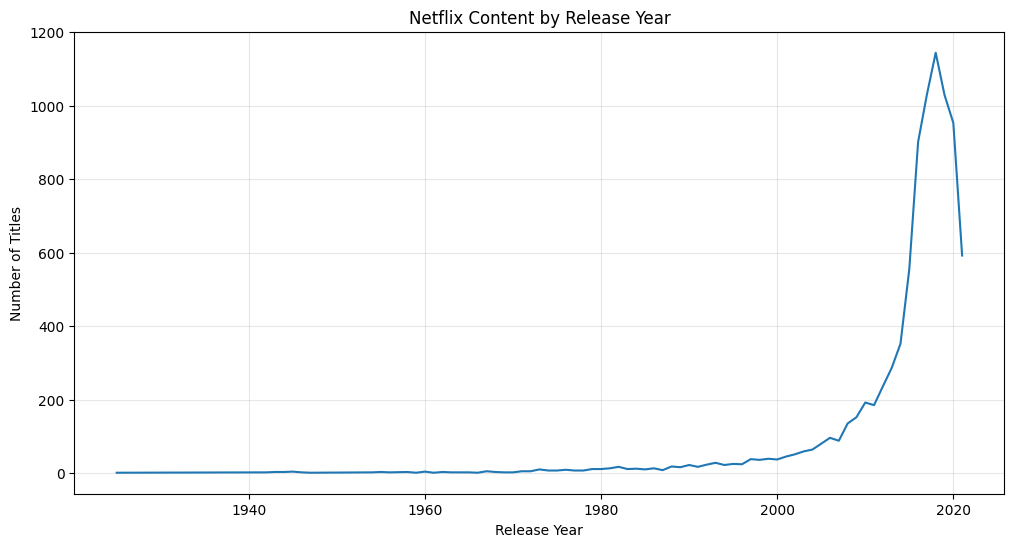

In [116]:
plt.figure(figsize=(12, 6))
plt.plot(yearly_content['release_year'],yearly_content['content_count'])
plt.title('Netflix Content by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(alpha=0.3)
plt.show()

In [117]:
recent_content = yearly_content[yearly_content['release_year'] >= 2007]

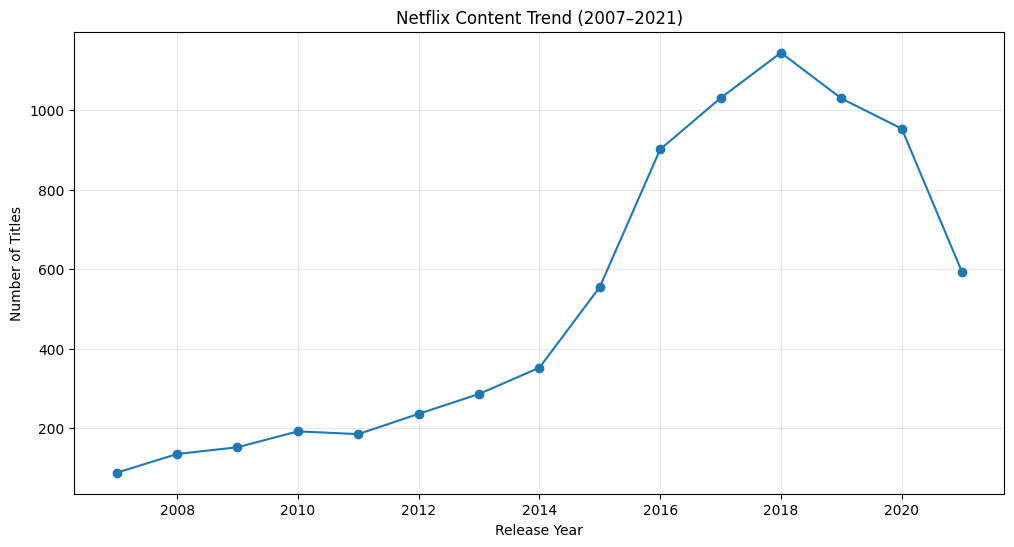

In [118]:
plt.figure(figsize=(12, 6))

plt.plot(recent_content['release_year'],recent_content['content_count'],marker='o')
plt.title('Netflix Content Trend (2007–2021)')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(alpha=0.3)
plt.show()

In [119]:
data['date_added'].max()

Timestamp('2021-09-25 00:00:00')

### Data Coverage Note

The dataset contains Netflix records added up to September 25, 2021. Therefore, 2021 represents only a partial year and may show an artificially lower content count.

To avoid introducing bias into the forecasting model, 2021 is excluded from the modeling period.

### Modeling Period Selection

The forecasting analysis focuses on the period from 2000 to 2020. Earlier years contain relatively sparse and irregular observations, while the period from 2000 onward provides a continuous annual series with a clearer modern content trend.

The year 2021 is excluded because the dataset only contains records added up to September 25, 2021, making it an incomplete year.

In [127]:
model_data = yearly_content[(yearly_content['release_year'] >= 2000) &(yearly_content['release_year'] <= 2020)].copy()
model_data

,release_year,content_count
52,2000,37
53,2001,45
54,2002,51
55,2003,59
56,2004,64
57,2005,80
58,2006,96
59,2007,88
60,2008,135
61,2009,152


In [128]:
yearly_type_content = (
    data.groupby(['release_year', 'type'])
        .size()
        .reset_index(name='content_count')
)

In [130]:
yearly_type_content = yearly_type_content[(yearly_type_content['release_year'] >= 2000) &(yearly_type_content['release_year'] <= 2020)]
yearly_type_content

,release_year,type,content_count
75,2000,Movie,33
76,2000,TV Show,4
77,2001,Movie,40
78,2001,TV Show,5
79,2002,Movie,44
80,2002,TV Show,7
81,2003,Movie,51
82,2003,TV Show,8
83,2004,Movie,55
84,2004,TV Show,9


## 3. Content Type Trend Analysis

The yearly content trend is analyzed separately for Movies and TV Shows to understand how each content type contributed to the overall growth pattern.

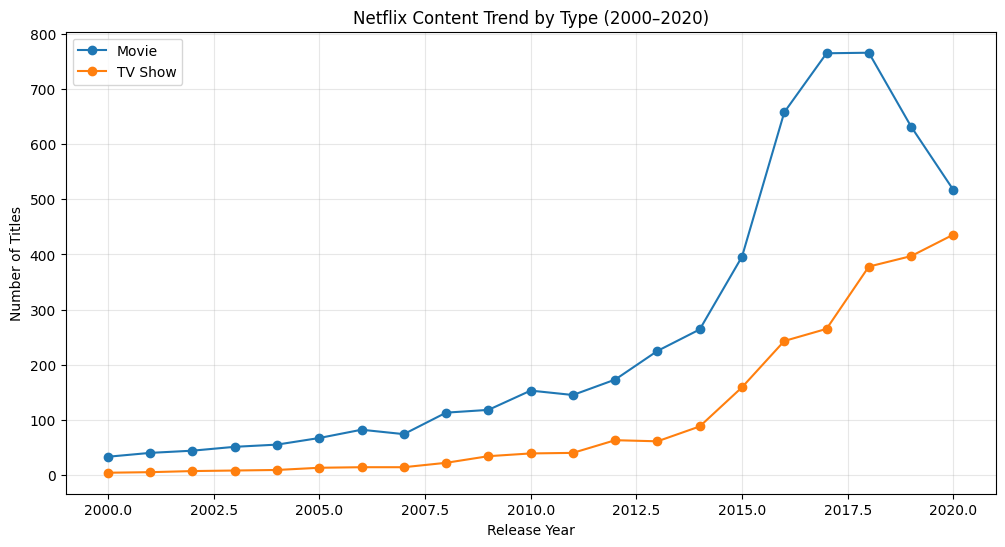

In [131]:
plt.figure(figsize=(12, 6))

for content_type in yearly_type_content['type'].unique():
    subset = yearly_type_content[
        yearly_type_content['type'] == content_type
    ]

    plt.plot(
        subset['release_year'],
        subset['content_count'],
        marker='o',
        label=content_type
    )

plt.title('Netflix Content Trend by Type (2000–2020)')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Key Insight

Movies accounted for most Netflix titles throughout the period and showed strong growth until 2017–2018, followed by a noticeable decline.

In contrast, TV Shows continued to grow through 2020, suggesting that the decline in overall content after 2018 was mainly driven by the decrease in movie titles.